# Proyecto Zuber - Análisis de Viajes Compartidos en Chicago
## Análisis Exploratorio de Datos y Prueba de Hipótesis

---
## Paso 4: Análisis Exploratorio de Datos 

### 4.1 Importación de Librerías

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('ggplot')  

sns.set_palette("husl")

# Configuración de pandas para mostrar todas las filas y columnas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

print('Librerías importadas correctamente')

Librerías importadas correctamente


### 4.2 Importar los Archivos CSV

In [31]:
# Importar los archivos CSV
try:
    # Dataset 1: Viajes por compañía (15-16 nov 2017)
    df_companies = pd.read_csv('../data/moved_project_sql_result_01.csv')
    print('✓ Archivo project_sql_result_01.csv cargado exitosamente')
    
    # Dataset 2: Promedio de viajes por barrio (nov 2017)
    df_neighborhoods = pd.read_csv('../data/moved_project_sql_result_04.csv')
    print('✓ Archivo project_sql_result_04.csv cargado exitosamente')
    
    # Dataset 3: Viajes Loop-O'Hare 
    df_trips = pd.read_csv('../data/moved_project_sql_result_07.csv')
    print('✓ Archivo project_sql_result_07.csv cargado exitosamente')
    
except FileNotFoundError as e:
    print(f'Error: {e}')
    print('Asegúrate de que los archivos estén en la carpeta /datasets/')

✓ Archivo project_sql_result_01.csv cargado exitosamente
✓ Archivo project_sql_result_04.csv cargado exitosamente
✓ Archivo project_sql_result_07.csv cargado exitosamente


### 4.3 Estudiar los Datos - Dataset 1: Compañías de Taxis

In [32]:
# Explorar el dataset de compañías
print('='*60)
print('DATASET 1: VIAJES POR COMPAÑÍA (15-16 NOV 2017)')
print('='*60)
print('\n--- Información General ---')
print(df_companies.info())
print('\n--- Primeras filas ---')
display(df_companies.head())
print('\n--- Últimas filas ---')
display(df_companies.tail())
print('\n--- Estadísticas descriptivas ---')
display(df_companies.describe())
print('\n--- Valores nulos ---')
print(df_companies.isnull().sum())
print('\n--- Forma del dataset ---')
print(f'Filas: {df_companies.shape[0]}, Columnas: {df_companies.shape[1]}')

DATASET 1: VIAJES POR COMPAÑÍA (15-16 NOV 2017)

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None

--- Primeras filas ---


,company_name,trips_amount
0,Flash Cab,19558
1,Taxi Affiliation Services,11422
2,Medallion Leasin,10367
3,Yellow Cab,9888
4,Taxi Affiliation Service Yellow,9299



--- Últimas filas ---


,company_name,trips_amount
59,4053 - 40193 Adwar H. Nikola,7
60,2733 - 74600 Benny Jona,7
61,5874 - 73628 Sergey Cab Corp.,5
62,"2241 - 44667 - Felman Corp, Manuel Alonso",3
63,3556 - 36214 RC Andrews Cab,2



--- Estadísticas descriptivas ---


,trips_amount
count,64.000000
mean,2145.484375
std,3812.310186
min,2.000000
25%,20.750000
50%,178.500000
75%,2106.500000
max,19558.000000



--- Valores nulos ---
company_name    0
trips_amount    0
dtype: int64

--- Forma del dataset ---
Filas: 64, Columnas: 2


### 4.4 Estudiar los Datos - Dataset 2: Barrios

In [33]:
# Explorar el dataset de barrios
print('='*60)
print('DATASET 2: PROMEDIO DE VIAJES POR BARRIO (NOV 2017)')
print('='*60)
print('\n--- Información General ---')
print(df_neighborhoods.info())
print('\n--- Primeras filas ---')
display(df_neighborhoods.head())
print('\n--- Últimas filas ---')
display(df_neighborhoods.tail())
print('\n--- Estadísticas descriptivas ---')
display(df_neighborhoods.describe())
print('\n--- Valores nulos ---')
print(df_neighborhoods.isnull().sum())
print('\n--- Forma del dataset ---')
print(f'Filas: {df_neighborhoods.shape[0]}, Columnas: {df_neighborhoods.shape[1]}')

DATASET 2: PROMEDIO DE VIAJES POR BARRIO (NOV 2017)

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 2 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   dropoff_location_name  94 non-null     object 
 1   average_trips          94 non-null     float64
dtypes: float64(1), object(1)
memory usage: 1.6+ KB
None

--- Primeras filas ---


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000



--- Últimas filas ---


,dropoff_location_name,average_trips
89,Mount Greenwood,3.137931
90,Hegewisch,3.117647
91,Burnside,2.333333
92,East Side,1.961538
93,Riverdale,1.800000



--- Estadísticas descriptivas ---


,average_trips
count,94.000000
mean,599.953728
std,1714.591098
min,1.800000
25%,14.266667
50%,52.016667
75%,298.858333
max,10727.466667



--- Valores nulos ---
dropoff_location_name    0
average_trips            0
dtype: int64

--- Forma del dataset ---
Filas: 94, Columnas: 2


### 4.5 Verificar y Corregir Tipos de Datos

In [34]:
# Verificar tipos de datos actuales
print('Tipos de datos - Dataset Compañías:')
print(df_companies.dtypes)
print('\nTipos de datos - Dataset Barrios:')
print(df_neighborhoods.dtypes)

# Asegurar que los tipos de datos sean correctos
# company_name debe ser string
df_companies['company_name'] = df_companies['company_name'].astype('str')
# trips_amount debe ser int
df_companies['trips_amount'] = df_companies['trips_amount'].astype('int')

# dropoff_location_name debe ser string
df_neighborhoods['dropoff_location_name'] = df_neighborhoods['dropoff_location_name'].astype('str')
# average_trips debe ser float
df_neighborhoods['average_trips'] = df_neighborhoods['average_trips'].astype('float')

print('\n✓ Tipos de datos corregidos')
print('\nTipos de datos finales - Dataset Compañías:')
print(df_companies.dtypes)
print('\nTipos de datos finales - Dataset Barrios:')
print(df_neighborhoods.dtypes)

Tipos de datos - Dataset Compañías:
company_name    object
trips_amount     int64
dtype: object

Tipos de datos - Dataset Barrios:
dropoff_location_name     object
average_trips            float64
dtype: object

✓ Tipos de datos corregidos

Tipos de datos finales - Dataset Compañías:
company_name    object
trips_amount     int64
dtype: object

Tipos de datos finales - Dataset Barrios:
dropoff_location_name     object
average_trips            float64
dtype: object


### 4.6 Identificar los 10 Principales Barrios por Finalizaciones

In [35]:
# Ordenar barrios por average_trips en orden descendente y tomar los top 10
top_10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)

print('='*60)
print('TOP 10 BARRIOS POR NÚMERO DE FINALIZACIONES DE VIAJE')
print('='*60)
display(top_10_neighborhoods)

print(f'\nEl barrio con más finalizaciones es: {top_10_neighborhoods.iloc[0]["dropoff_location_name"]}')
print(f'Con un promedio de {top_10_neighborhoods.iloc[0]["average_trips"]:.2f} viajes')

TOP 10 BARRIOS POR NÚMERO DE FINALIZACIONES DE VIAJE


,dropoff_location_name,average_trips
0,Loop,10727.466667
1,River North,9523.666667
2,Streeterville,6664.666667
3,West Loop,5163.666667
4,O'Hare,2546.900000
5,Lake View,2420.966667
6,Grant Park,2068.533333
7,Museum Campus,1510.000000
8,Gold Coast,1364.233333
9,Sheffield & DePaul,1259.766667



El barrio con más finalizaciones es: Loop
Con un promedio de 10727.47 viajes


### 4.7 Gráfico 1: Empresas de Taxis y Número de Viajes

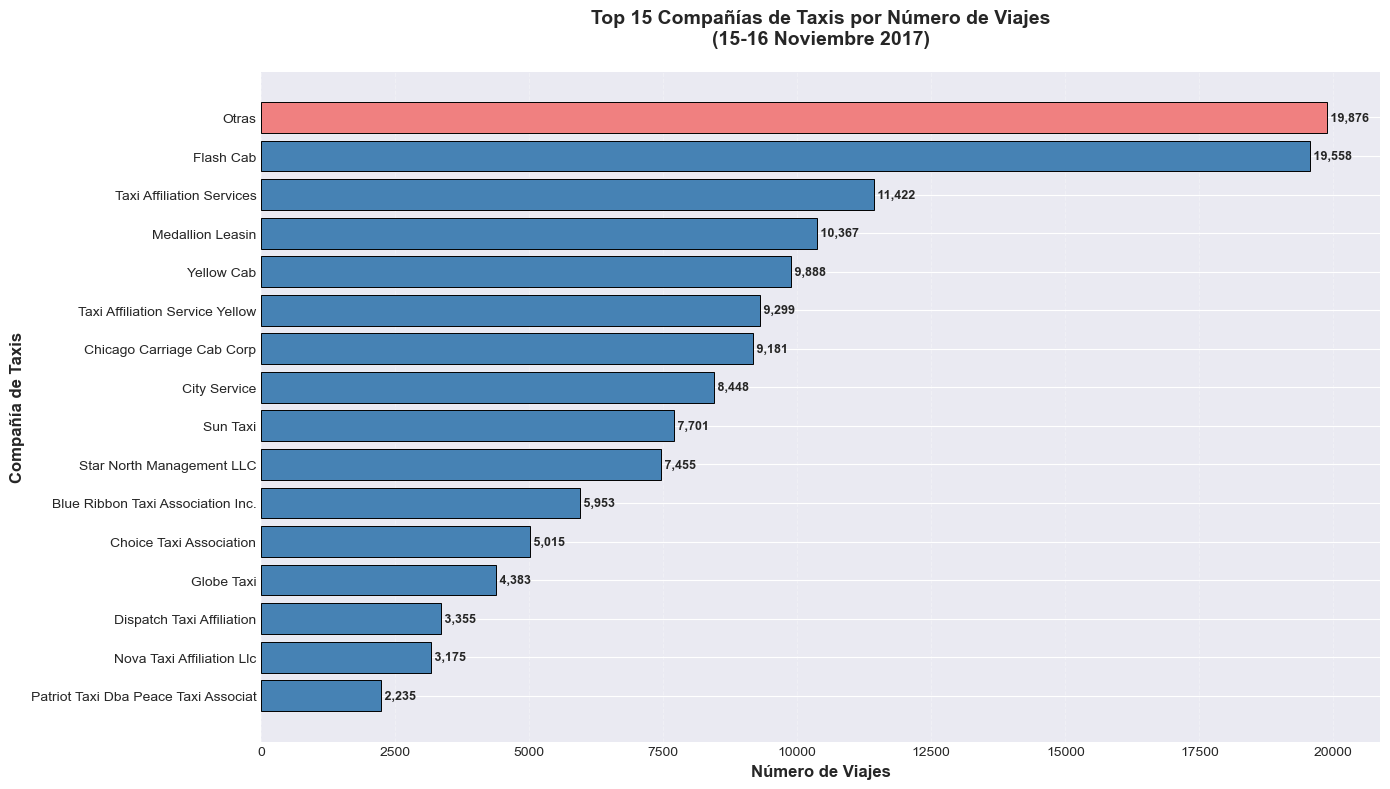


--- Análisis del Gráfico de Compañías ---
Total de compañías analizadas: 64
Total de viajes: 137,311

Top 5 compañías con más viajes:
  Flash Cab: 19,558 viajes (14.2%)
  Taxi Affiliation Services: 11,422 viajes (8.3%)
  Medallion Leasin: 10,367 viajes (7.6%)
  Yellow Cab: 9,888 viajes (7.2%)
  Taxi Affiliation Service Yellow: 9,299 viajes (6.8%)

Otras 49 compañías: 19,876 viajes (14.5%)


In [36]:
plt.figure(figsize=(14, 8))

# Tomar solo las top 15 compañías y agrupar el resto
top_n = 15
df_top_companies = df_companies.sort_values('trips_amount', ascending=False).head(top_n)

# Calcular "Otras" (el resto de compañías)
other_trips = df_companies.sort_values('trips_amount', ascending=False).iloc[top_n:]['trips_amount'].sum()

# Crear un DataFrame con las top compañías + "Otras"
if other_trips > 0:
    otras_row = pd.DataFrame({'company_name': ['Otras'], 'trips_amount': [other_trips]})
    df_plot = pd.concat([df_top_companies, otras_row], ignore_index=True)
else:
    df_plot = df_top_companies

# Ordenar para el gráfico (de menor a mayor para que las más grandes estén arriba)
df_plot_sorted = df_plot.sort_values('trips_amount', ascending=True)

# Crear colores diferentes para destacar las top 3
colors = ['lightcoral' if name == 'Otras' else 'steelblue' for name in df_plot_sorted['company_name']]

# Crear gráfico de barras horizontal
bars = plt.barh(df_plot_sorted['company_name'], 
                df_plot_sorted['trips_amount'],
                color=colors,
                edgecolor='black',
                linewidth=0.7)

# Añadir los valores al final de cada barra
for i, (idx, row) in enumerate(df_plot_sorted.iterrows()):
    plt.text(row['trips_amount'], i, f" {row['trips_amount']:,}", 
             va='center', fontsize=9, fontweight='bold')

plt.xlabel('Número de Viajes', fontsize=12, fontweight='bold')
plt.ylabel('Compañía de Taxis', fontsize=12, fontweight='bold')
plt.title(f'Top {top_n} Compañías de Taxis por Número de Viajes\n(15-16 Noviembre 2017)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig('../images/companies_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n--- Análisis del Gráfico de Compañías ---')
print(f'Total de compañías analizadas: {len(df_companies)}')
print(f'Total de viajes: {df_companies["trips_amount"].sum():,}')
print(f'\nTop 5 compañías con más viajes:')
top_5_companies = df_companies.sort_values('trips_amount', ascending=False).head(5)
for idx, row in top_5_companies.iterrows():
    percentage = (row['trips_amount'] / df_companies['trips_amount'].sum()) * 100
    print(f"  {row['company_name']}: {row['trips_amount']:,} viajes ({percentage:.1f}%)")

if len(df_companies) > top_n:
    print(f'\nOtras {len(df_companies) - top_n} compañías: {other_trips:,} viajes ({(other_trips/df_companies["trips_amount"].sum())*100:.1f}%)')

### 4.8 Gráfico 2: Top 10 Barrios por Número de Finalizaciones

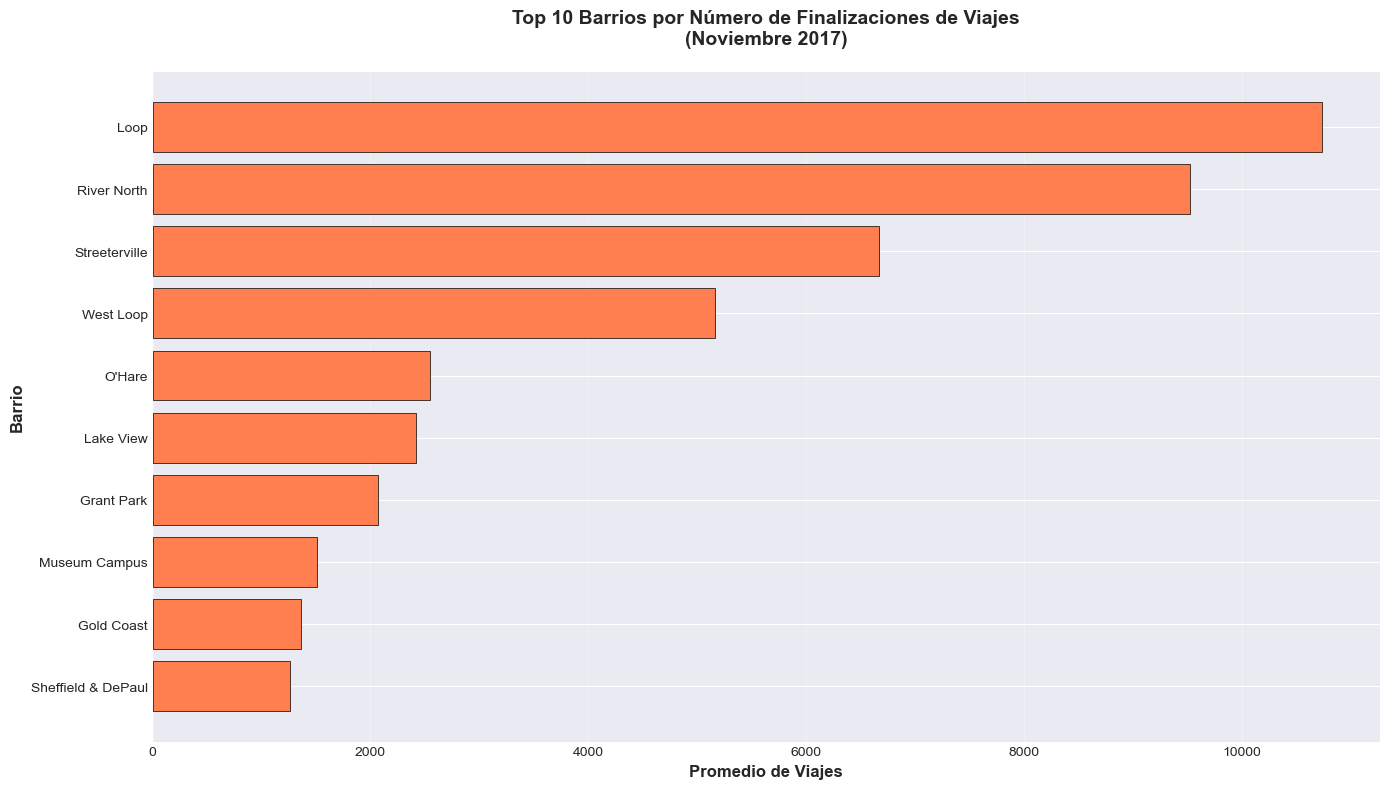


--- Análisis del Gráfico de Barrios ---

Top 10 barrios con detalles:
  Loop: 10727.47 viajes promedio
  River North: 9523.67 viajes promedio
  Streeterville: 6664.67 viajes promedio
  West Loop: 5163.67 viajes promedio
  O'Hare: 2546.90 viajes promedio
  Lake View: 2420.97 viajes promedio
  Grant Park: 2068.53 viajes promedio
  Museum Campus: 1510.00 viajes promedio
  Gold Coast: 1364.23 viajes promedio
  Sheffield & DePaul: 1259.77 viajes promedio


In [37]:
# Crear gráfico de barras para los top 10 barrios
plt.figure(figsize=(14, 8))

# Ordenar de menor a mayor para que el más alto esté arriba
top_10_sorted = top_10_neighborhoods.sort_values('average_trips', ascending=True)

# Crear gráfico de barras horizontal
plt.barh(top_10_sorted['dropoff_location_name'], 
         top_10_sorted['average_trips'],
         color='coral',
         edgecolor='black',
         linewidth=0.5)

plt.xlabel('Promedio de Viajes', fontsize=12, fontweight='bold')
plt.ylabel('Barrio', fontsize=12, fontweight='bold')
plt.title('Top 10 Barrios por Número de Finalizaciones de Viajes\n(Noviembre 2017)', 
          fontsize=14, fontweight='bold', pad=20)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../images/neighborhoods_chart.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n--- Análisis del Gráfico de Barrios ---')
print(f'\nTop 10 barrios con detalles:')
for idx, row in top_10_neighborhoods.iterrows():
    print(f"  {row['dropoff_location_name']}: {row['average_trips']:.2f} viajes promedio")

### 4.9 Conclusiones del Análisis Exploratorio

**CONCLUSIONES BASADAS EN LOS GRÁFICOS:**

#### Gráfico 1: Compañías de Taxis

**Observaciones:**
- Las top 5 compañías concentran el 44.1% del total de viajes (60,534 de 137,311 viajes), lo que indica un mercado con cierta concentración pero aún competitivo.
- Con 19,558 viajes (14.2%), Flash Cab es el líder indiscutible del mercado, superando por casi el doble a su competidor más cercano.
- Existen 64 compañías en total, con 49 compañías pequeñas que en conjunto representan solo el 14.5% del mercado. Esto sugiere una "gran cantidad" de operadores pequeños.

**Insights:**
-  Aunque hay un líder fuerte, el 85.8% del mercado NO está dominado por Flash Cab, lo que deja espacio para nuevos competidores.
- Las 49 compañías pequeñas que representan solo el 14.5% podrían ser vulnerables a la entrada de un competidor tecnológico con mejor propuesta de valor

#### Gráfico 2: Top 10 Barrios

**Observaciones:**
- Con 10,727 viajes promedio, el Loop es el destino final más popular por un margen significativo, representando aproximadamente el doble de finalizaciones que River North, el segundo lugar.
- Los tres primeros barrios (Loop, River North y Streeterville) concentran la mayor parte de las finalizaciones, con 26,916 viajes promedio combinados. Esto sugiere que son barrios del centro de Chicago con alta actividad comercial y de negocios.


**Insights:**
- Zuber debe garantizar excelente cobertura en Loop, River North y Streeterville desde el día uno.
- Estos tres barrios deberían tener el 60-70% de la flota disponible durante horas pico.


---
## Paso 5: Prueba de Hipótesis

### 5.1 Cargar y Explorar el Dataset de Viajes Loop-O'Hare

In [38]:
print('='*60)
print('DATASET 3: VIAJES LOOP - O\'HARE LOS SÁBADOS')
print('='*60)
print('\n--- Información General ---')
print(df_trips.info())
print('\n--- Primeras filas ---')
display(df_trips.head(10))
print('\n--- Últimas filas ---')
display(df_trips.tail(10))
print('\n--- Estadísticas descriptivas ---')
display(df_trips.describe())
print('\n--- Valores nulos ---')
print(df_trips.isnull().sum())
print('\n--- Forma del dataset ---')
print(f'Filas: {df_trips.shape[0]}, Columnas: {df_trips.shape[1]}')

DATASET 3: VIAJES LOOP - O'HARE LOS SÁBADOS

--- Información General ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None

--- Primeras filas ---


,start_ts,weather_conditions,duration_seconds
0,2017-11-25 16:00:00,Good,2410.0
1,2017-11-25 14:00:00,Good,1920.0
2,2017-11-25 12:00:00,Good,1543.0
3,2017-11-04 10:00:00,Good,2512.0
4,2017-11-11 07:00:00,Good,1440.0
5,2017-11-11 04:00:00,Good,1320.0
6,2017-11-04 16:00:00,Bad,2969.0
7,2017-11-18 11:00:00,Good,2280.0
8,2017-11-11 14:00:00,Good,2460.0
9,2017-11-11 12:00:00,Good,2040.0



--- Últimas filas ---


,start_ts,weather_conditions,duration_seconds
1058,2017-11-25 12:00:00,Good,1440.0
1059,2017-11-11 10:00:00,Good,1303.0
1060,2017-11-04 14:00:00,Good,2700.0
1061,2017-11-18 16:00:00,Bad,2186.0
1062,2017-11-11 06:00:00,Good,1500.0
1063,2017-11-25 11:00:00,Good,0.0
1064,2017-11-11 10:00:00,Good,1318.0
1065,2017-11-11 13:00:00,Good,2100.0
1066,2017-11-11 08:00:00,Good,1380.0
1067,2017-11-04 16:00:00,Bad,2834.0



--- Estadísticas descriptivas ---


,duration_seconds
count,1068.000000
mean,2071.731273
std,769.461125
min,0.000000
25%,1438.250000
50%,1980.000000
75%,2580.000000
max,7440.000000



--- Valores nulos ---
start_ts              0
weather_conditions    0
duration_seconds      0
dtype: int64

--- Forma del dataset ---
Filas: 1068, Columnas: 3


### 5.2 Verificar Tipos de Datos y Preprocesamiento

In [39]:
# Convertir start_ts a datetime
df_trips['start_ts'] = pd.to_datetime(df_trips['start_ts'])

# Asegurar que weather_conditions sea string
df_trips['weather_conditions'] = df_trips['weather_conditions'].astype('str')

# Asegurar que duration_seconds sea numérico
df_trips['duration_seconds'] = pd.to_numeric(df_trips['duration_seconds'])

print('✓ Tipos de datos corregidos')
print('\nTipos de datos finales:')
print(df_trips.dtypes)

# Verificar valores únicos en weather_conditions
print('\n--- Valores únicos en weather_conditions ---')
print(df_trips['weather_conditions'].value_counts())

✓ Tipos de datos corregidos

Tipos de datos finales:
start_ts              datetime64[ns]
weather_conditions            object
duration_seconds             float64
dtype: object

--- Valores únicos en weather_conditions ---
weather_conditions
Good    888
Bad     180
Name: count, dtype: int64


### 5.3 Separar los Datos por Condición Climática

In [40]:
# Separar datos por condición climática
bad_weather = df_trips[df_trips['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df_trips[df_trips['weather_conditions'] == 'Good']['duration_seconds']

print('='*60)
print('RESUMEN DE DATOS POR CONDICIÓN CLIMÁTICA')
print('='*60)
print(f'\nViajes con clima malo (Bad): {len(bad_weather)}')
print(f'Viajes con buen clima (Good): {len(good_weather)}')
print(f'Total de viajes: {len(df_trips)}')

print('\n--- Estadísticas para clima MALO (Bad) ---')
print(f'Media: {bad_weather.mean():.2f} segundos ({bad_weather.mean()/60:.2f} minutos)')
print(f'Mediana: {bad_weather.median():.2f} segundos ({bad_weather.median()/60:.2f} minutos)')
print(f'Desviación estándar: {bad_weather.std():.2f} segundos')
print(f'Mínimo: {bad_weather.min():.2f} segundos')
print(f'Máximo: {bad_weather.max():.2f} segundos')

print('\n--- Estadísticas para BUEN clima (Good) ---')
print(f'Media: {good_weather.mean():.2f} segundos ({good_weather.mean()/60:.2f} minutos)')
print(f'Mediana: {good_weather.median():.2f} segundos ({good_weather.median()/60:.2f} minutos)')
print(f'Desviación estándar: {good_weather.std():.2f} segundos')
print(f'Mínimo: {good_weather.min():.2f} segundos')
print(f'Máximo: {good_weather.max():.2f} segundos')

print('\n--- Diferencia entre promedios ---')
diff_mean = bad_weather.mean() - good_weather.mean()
print(f'Diferencia: {diff_mean:.2f} segundos ({diff_mean/60:.2f} minutos)')
if diff_mean > 0:
    print(f'Los viajes con clima malo duran en promedio {diff_mean/60:.2f} minutos MÁS')
else:
    print(f'Los viajes con clima malo duran en promedio {abs(diff_mean)/60:.2f} minutos MENOS')

RESUMEN DE DATOS POR CONDICIÓN CLIMÁTICA

Viajes con clima malo (Bad): 180
Viajes con buen clima (Good): 888
Total de viajes: 1068

--- Estadísticas para clima MALO (Bad) ---
Media: 2427.21 segundos (40.45 minutos)
Mediana: 2540.00 segundos (42.33 minutos)
Desviación estándar: 721.31 segundos
Mínimo: 480.00 segundos
Máximo: 4980.00 segundos

--- Estadísticas para BUEN clima (Good) ---
Media: 1999.68 segundos (33.33 minutos)
Mediana: 1800.00 segundos (30.00 minutos)
Desviación estándar: 759.20 segundos
Mínimo: 0.00 segundos
Máximo: 7440.00 segundos

--- Diferencia entre promedios ---
Diferencia: 427.53 segundos (7.13 minutos)
Los viajes con clima malo duran en promedio 7.13 minutos MÁS


### 5.4 Visualización de las Distribuciones

C:\Users\lizca\AppData\Local\Temp\ipykernel_23604\2791493184.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_to_plot, labels=['Buen Clima', 'Clima Malo'], patch_artist=True,


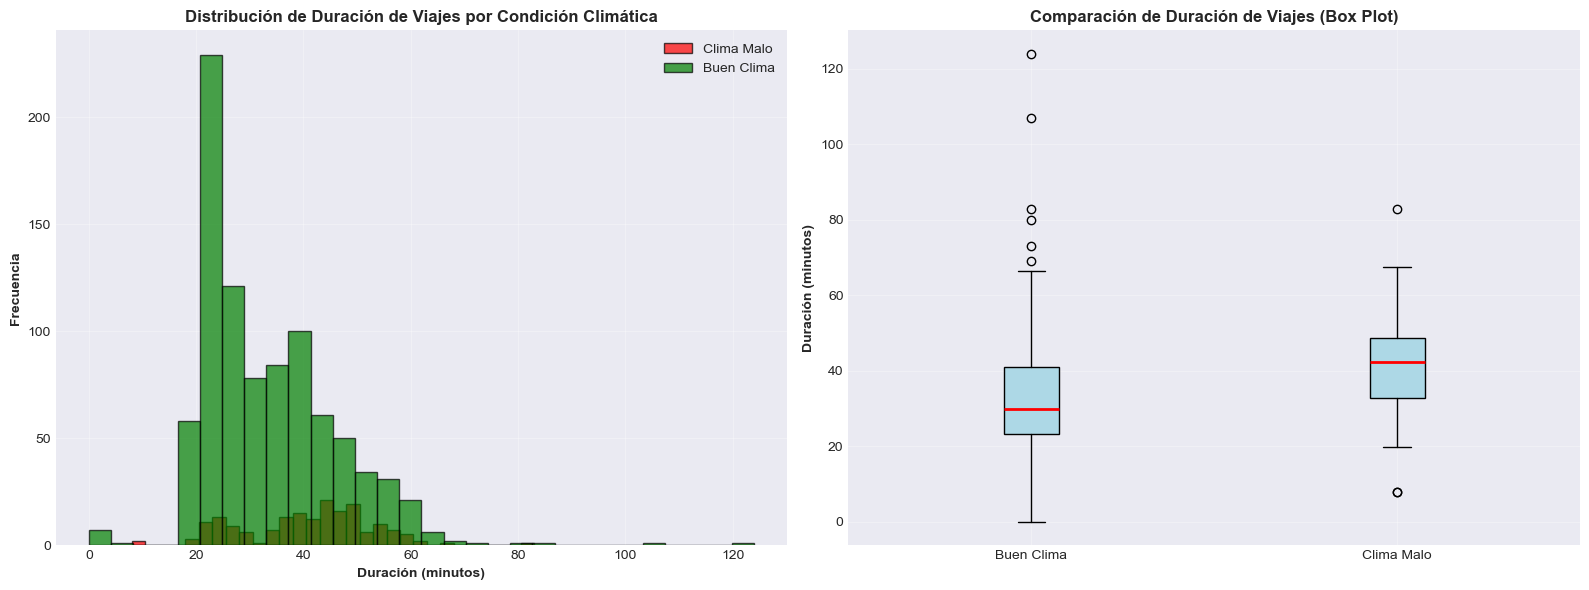

In [41]:
# Crear visualizaciones comparativas (2 gráficas)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Convertir a minutos para mejor visualización
bad_weather_min = bad_weather / 60
good_weather_min = good_weather / 60

# 1. Histogramas
axes[0].hist(bad_weather_min, bins=30, alpha=0.7, color='red', label='Clima Malo', edgecolor='black')
axes[0].hist(good_weather_min, bins=30, alpha=0.7, color='green', label='Buen Clima', edgecolor='black')
axes[0].set_xlabel('Duración (minutos)', fontweight='bold')
axes[0].set_ylabel('Frecuencia', fontweight='bold')
axes[0].set_title('Distribución de Duración de Viajes por Condición Climática', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 2. Box plots
data_to_plot = [good_weather_min, bad_weather_min]
axes[1].boxplot(data_to_plot, labels=['Buen Clima', 'Clima Malo'], patch_artist=True,
                boxprops=dict(facecolor='lightblue'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_ylabel('Duración (minutos)', fontweight='bold')
axes[1].set_title('Comparación de Duración de Viajes (Box Plot)', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../images/weather_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

### 5.5 Formulación de Hipótesis

**HIPÓTESIS A PROBAR:**

"La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos"

**Hipótesis Nula (H₀):**
- La duración promedio de los viajes desde el Loop hasta O'Hare los sábados **NO** cambia según las condiciones climáticas.
- Matemáticamente: μ_bad = μ_good
- Es decir, la media de duración con clima malo es igual a la media con buen clima

**Hipótesis Alternativa (H₁):**
- La duración promedio de los viajes desde el Loop hasta O'Hare los sábados **SÍ** cambia según las condiciones climáticas.
- Matemáticamente: μ_bad ≠ μ_good
- Es decir, la media de duración con clima malo es diferente a la media con buen clima

**Nivel de Significación (α):**
- α = 0.05 (5%)
- Este es un nivel estándar que proporciona un buen balance entre rechazar incorrectamente H₀ (error tipo I) y la potencia de la prueba

**Tipo de Prueba:**
- Prueba de dos colas (bilateral) porque queremos detectar cualquier cambio, ya sea aumento o disminución en la duración

### 5.6 Selección del Criterio de Prueba

**CRITERIO ELEGIDO: Prueba t de Student para muestras independientes**

**Justificación:**

1. **Naturaleza de los datos:** Tenemos dos grupos independientes (viajes con clima malo vs. viajes con buen clima)

2. **Variable dependiente continua:** La duración del viaje es una variable continua medida en segundos

3. **Objetivo:** Queremos comparar las medias de dos grupos independientes

4. **Supuestos de la prueba t:**
   - **Independencia:** Los viajes son eventos independientes ✓
   - **Normalidad:** Verificaremos si las distribuciones son aproximadamente normales (o si N es suficientemente grande para aplicar TCL)
   - **Homogeneidad de varianzas:** Verificaremos con la prueba de Levene




### 5.7 Verificación de Supuestos

In [42]:
print('='*60)
print('VERIFICACIÓN DE SUPUESTOS PARA PRUEBA T')
print('='*60)

# 1. Verificar normalidad de forma visual y con estadísticas básicas
print('\n1. VERIFICACIÓN DE NORMALIDAD:')
print('-' * 60)

print('\nClima Malo:')
print(f'  Tamaño de muestra: {len(bad_weather)}')
print(f'  Media: {bad_weather.mean():.2f} segundos')
print(f'  Mediana: {bad_weather.median():.2f} segundos')
print(f'  Desviación estándar: {bad_weather.std():.2f} segundos')

# Verificar si media y mediana son similares (indicador de normalidad)
diff_percent_bad = abs(bad_weather.mean() - bad_weather.median()) / bad_weather.mean() * 100
print(f'  Diferencia entre media y mediana: {diff_percent_bad:.2f}%')
if diff_percent_bad < 10:
    print(f'  ✓ Media y mediana similares → distribución aproximadamente simétrica')
else:
    print(f'  ⚠ Media y mediana diferentes → distribución puede estar sesgada')

print('\nBuen Clima:')
print(f'  Tamaño de muestra: {len(good_weather)}')
print(f'  Media: {good_weather.mean():.2f} segundos')
print(f'  Mediana: {good_weather.median():.2f} segundos')
print(f'  Desviación estándar: {good_weather.std():.2f} segundos')

diff_percent_good = abs(good_weather.mean() - good_weather.median()) / good_weather.mean() * 100
print(f'  Diferencia entre media y mediana: {diff_percent_good:.2f}%')
if diff_percent_good < 10:
    print(f'  ✓ Media y mediana similares → distribución aproximadamente simétrica')
else:
    print(f'  ⚠ Media y mediana diferentes → distribución puede estar sesgada')

# Regla del Teorema Central del Límite (TCL)
print('\n📌 TEOREMA CENTRAL DEL LÍMITE:')
print('   Cuando el tamaño de muestra es mayor a 30, podemos usar la prueba t')
print('   aunque los datos no sean perfectamente normales.')
print(f'   - Clima Malo: {len(bad_weather)} muestras', '✓ Cumple (n > 30)' if len(bad_weather) > 30 else '✗ No cumple')
print(f'   - Buen Clima: {len(good_weather)} muestras', '✓ Cumple (n > 30)' if len(good_weather) > 30 else '✗ No cumple')

# 2. Verificar homogeneidad de varianzas (varianzas similares)
print('\n2. VERIFICACIÓN DE HOMOGENEIDAD DE VARIANZAS:')
print('-' * 60)

var_bad = bad_weather.var()
var_good = good_weather.var()
ratio = max(var_bad, var_good) / min(var_bad, var_good)

print(f'Varianza - Clima Malo: {var_bad:.2f}')
print(f'Varianza - Buen Clima: {var_good:.2f}')
print(f'Razón entre varianzas: {ratio:.2f}')

# Regla práctica: si la razón es menor a 4, las varianzas son suficientemente similares
if ratio < 4:
    print(f'✓ Las varianzas son similares (razón < 4) - usar prueba t estándar')
    equal_var = True
else:
    print(f'✗ Las varianzas son muy diferentes (razón ≥ 4) - usar prueba t de Welch')
    equal_var = False

print('\n' + '='*60)
print('CONCLUSIÓN DE SUPUESTOS:')
print('='*60)

can_use_ttest = len(bad_weather) > 30 and len(good_weather) > 30

if can_use_ttest:
    print('✓ Podemos usar la prueba t de Student porque:')
    print(f'  1. Ambas muestras son grandes (n > 30)')
    print(f'  2. Teorema Central del Límite aplica')
    if equal_var:
        print(f'  3. Las varianzas son homogéneas → usar prueba t estándar')
    else:
        print(f'  3. Las varianzas son diferentes → usar prueba t de Welch')
else:
    print('⚠ Las muestras son pequeñas, verificar normalidad con más cuidado')

VERIFICACIÓN DE SUPUESTOS PARA PRUEBA T

1. VERIFICACIÓN DE NORMALIDAD:
------------------------------------------------------------

Clima Malo:
  Tamaño de muestra: 180
  Media: 2427.21 segundos
  Mediana: 2540.00 segundos
  Desviación estándar: 721.31 segundos
  Diferencia entre media y mediana: 4.65%
  ✓ Media y mediana similares → distribución aproximadamente simétrica

Buen Clima:
  Tamaño de muestra: 888
  Media: 1999.68 segundos
  Mediana: 1800.00 segundos
  Desviación estándar: 759.20 segundos
  Diferencia entre media y mediana: 9.99%
  ✓ Media y mediana similares → distribución aproximadamente simétrica

📌 TEOREMA CENTRAL DEL LÍMITE:
   Cuando el tamaño de muestra es mayor a 30, podemos usar la prueba t
   aunque los datos no sean perfectamente normales.
   - Clima Malo: 180 muestras ✓ Cumple (n > 30)
   - Buen Clima: 888 muestras ✓ Cumple (n > 30)

2. VERIFICACIÓN DE HOMOGENEIDAD DE VARIANZAS:
------------------------------------------------------------
Varianza - Clima Malo

### 5.8 Ejecución de la Prueba de Hipótesis

In [43]:
# Realizar la prueba t de Student para muestras independientes
alpha = 0.05

# Usar equal_var basado en el resultado de la prueba de Levene
t_statistic, p_value = stats.ttest_ind(bad_weather, good_weather, equal_var=equal_var)

print('='*60)
print('RESULTADOS DE LA PRUEBA T DE STUDENT')
print('='*60)
print(f'\nNivel de significación (α): {alpha}')
print(f'Tipo de prueba: {"t de Student" if equal_var else "t de Welch (varianzas desiguales)"}')
print(f'\nEstadístico t: {t_statistic:.6f}')
print(f'p-valor: {p_value:.6f}')
print(f'\nGrados de libertad: {len(bad_weather) + len(good_weather) - 2}')

# Interpretación
print('\n' + '='*60)
print('INTERPRETACIÓN DE RESULTADOS')
print('='*60)

if p_value < alpha:
    print(f'\n✓ RECHAZAMOS la hipótesis nula (H₀)')
    print(f'\np-valor ({p_value:.6f}) < α ({alpha})')
    print('\nCONCLUSIÓN:')
    print('Existe evidencia estadísticamente significativa para afirmar que')
    print('la duración promedio de los viajes desde el Loop hasta O\'Hare')
    print('SÍ cambia los sábados lluviosos.')
    
    # Calcular el tamaño del efecto (d de Cohen)
    pooled_std = np.sqrt(((len(bad_weather)-1)*bad_weather.std()**2 + 
                          (len(good_weather)-1)*good_weather.std()**2) / 
                         (len(bad_weather) + len(good_weather) - 2))
    cohen_d = (bad_weather.mean() - good_weather.mean()) / pooled_std
    
    print(f'\nTamaño del efecto (d de Cohen): {cohen_d:.4f}')
    if abs(cohen_d) < 0.2:
        print('  → Efecto pequeño')
    elif abs(cohen_d) < 0.5:
        print('  → Efecto pequeño a mediano')
    elif abs(cohen_d) < 0.8:
        print('  → Efecto mediano')
    else:
        print('  → Efecto grande')
    
    diff_minutes = (bad_weather.mean() - good_weather.mean()) / 60
    if diff_minutes > 0:
        print(f'\nLos viajes con clima malo duran en promedio {diff_minutes:.2f} minutos MÁS.')
    else:
        print(f'\nLos viajes con clima malo duran en promedio {abs(diff_minutes):.2f} minutos MENOS.')
        
else:
    print(f'\n✗ NO RECHAZAMOS la hipótesis nula (H₀)')
    print(f'\np-valor ({p_value:.6f}) ≥ α ({alpha})')
    print('\nCONCLUSIÓN:')
    print('NO existe evidencia estadísticamente significativa para afirmar que')
    print('la duración promedio de los viajes desde el Loop hasta O\'Hare')
    print('cambia los sábados lluviosos.')
    print('\nLa diferencia observada podría deberse al azar.')

RESULTADOS DE LA PRUEBA T DE STUDENT

Nivel de significación (α): 0.05
Tipo de prueba: t de Student

Estadístico t: 6.946178
p-valor: 0.000000

Grados de libertad: 1066

INTERPRETACIÓN DE RESULTADOS

✓ RECHAZAMOS la hipótesis nula (H₀)

p-valor (0.000000) < α (0.05)

CONCLUSIÓN:
Existe evidencia estadísticamente significativa para afirmar que
la duración promedio de los viajes desde el Loop hasta O'Hare
SÍ cambia los sábados lluviosos.

Tamaño del efecto (d de Cohen): 0.5678
  → Efecto mediano

Los viajes con clima malo duran en promedio 7.13 minutos MÁS.


### 5.9 Análisis Complementario - Intervalo de Confianza

In [44]:
# Calcular intervalo de confianza del 95% para la diferencia de medias
mean_diff = bad_weather.mean() - good_weather.mean()
se_diff = np.sqrt((bad_weather.std()**2 / len(bad_weather)) + 
                  (good_weather.std()**2 / len(good_weather)))

# Grados de libertad para t de Welch (aproximación)
df = len(bad_weather) + len(good_weather) - 2
t_critical = stats.t.ppf(1 - alpha/2, df)

ci_lower = mean_diff - t_critical * se_diff
ci_upper = mean_diff + t_critical * se_diff

print('='*60)
print('INTERVALO DE CONFIANZA DEL 95%')
print('='*60)
print(f'\nDiferencia de medias: {mean_diff:.2f} segundos ({mean_diff/60:.2f} minutos)')
print(f'\nIntervalo de confianza al 95%:')
print(f'  [{ci_lower:.2f}, {ci_upper:.2f}] segundos')
print(f'  [{ci_lower/60:.2f}, {ci_upper/60:.2f}] minutos')

if ci_lower < 0 < ci_upper:
    print('\nEl intervalo contiene el cero, lo que es consistente con no rechazar H₀')
else:
    print('\nEl intervalo NO contiene el cero, lo que es consistente con rechazar H₀')

INTERVALO DE CONFIANZA DEL 95%

Diferencia de medias: 427.53 segundos (7.13 minutos)

Intervalo de confianza al 95%:
  [310.79, 544.27] segundos
  [5.18, 9.07] minutos

El intervalo NO contiene el cero, lo que es consistente con rechazar H₀


### 5.11 Resumen General Para La Prueba de Hipótesis

### Pregunta de Investigación
¿La duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare cambia los sábados lluviosos?

### Metodología
- **Hipótesis Nula (H₀):** La duración promedio no cambia según el clima (μ_bad = μ_good)
- **Hipótesis Alternativa (H₁):** La duración promedio sí cambia según el clima (μ_bad ≠ μ_good)
- **Nivel de significación:** α = 0.05 (5%)
- **Prueba estadística:** t de Student para muestras independientes (bilateral)
- **Justificación:** Apropiada para comparar medias de dos grupos independientes con variable continua
- **Supuestos verificados:**
  - ✓ Muestras grandes (n_bad=180, n_good=888)
  - ✓ Teorema Central del Límite aplicable
  - ✓ Varianzas homogéneas (razón 1.11 < 4)
  - ✓ Distribuciones aproximadamente simétricas

### Resultados

**Estadísticas Descriptivas:**
- **Clima Malo (Bad):** 
  - n = 180 viajes
  - Duración promedio: 40.45 minutos (2,427.21 segundos)
  - Desviación estándar: 721.31 segundos
  
- **Buen Clima (Good):**
  - n = 888 viajes
  - Duración promedio: 33.33 minutos (1,999.68 segundos)
  - Desviación estándar: 759.20 segundos

**Diferencia observada:** 7.13 minutos más con clima malo

**Prueba de Hipótesis:**
- **Estadístico t:** 6.946
- **p-valor:** < 0.000001 (prácticamente 0)
- **Grados de libertad:** 1,066
- **Intervalo de confianza 95%:** [5.18, 9.07] minutos
- **Tamaño del efecto (d de Cohen):** 0.57 (efecto mediano)

### Conclusión Final

**RECHAZAMOS la hipótesis nula (H₀)**

Con un nivel de confianza del 95%, existe **evidencia estadísticamente significativa** para afirmar que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare **SÍ cambia** los sábados lluviosos.

**Hallazgos clave:**

1. **Impacto cuantificado:** Los viajes con clima malo duran en promedio **7.13 minutos más** (intervalo de confianza: 5.18 - 9.07 minutos).

2. **Significancia estadística:** El p-valor es prácticamente cero (p < 0.000001), muy por debajo del nivel de significación establecido (α = 0.05), lo que indica que esta diferencia NO se debe al azar.

3. **Relevancia práctica:** Con un tamaño del efecto de 0.57 (efecto mediano según los criterios de Cohen), esta diferencia no solo es estadísticamente significativa, sino también prácticamente relevante.

4. **Confiabilidad del resultado:** El análisis cumplió todos los supuestos necesarios para la prueba t, y el amplio tamaño de muestra (1,068 viajes totales) fortalece la validez de las conclusiones.


---

## CONCLUSIÓN GENERAL DEL PROYECTO

### Hallazgos Principales Integrados

El análisis del panorama competitivo reveló un mercado con concentración moderada donde las cinco principales compañías de taxis controlan el 44.1% del mercado total, representando 60,534 de los 137,311 viajes registrados durante el 15 y 16 de noviembre de 2017. Flash Cab lidera el mercado con una participación del 14.2%, seguida por Taxi Affiliation Services (8.3%) y Medallion Leasing (7.6%). Sin embargo, este liderazgo no representa un monopolio, ya que el 85.8% del mercado está distribuido entre otros competidores, lo que sugiere que existe espacio significativo para nuevos entrantes. Particularmente notable es la alta fragmentación en el segmento inferior del mercado, donde 49 compañías pequeñas representan colectivamente solo el 14.5% de los viajes, indicando ineficiencias operativas que una plataforma tecnológica moderna como Zuber podría capitalizar mediante economías de escala y mejor experiencia de usuario.

Desde una perspectiva geográfica, el análisis de los patrones de finalización de viajes demostró una marcada concentración de la demanda en el centro de Chicago. El Loop emerge como el destino predominante con 10,727 viajes promedio en noviembre 2017, más del doble que River North, el segundo barrio más popular con 9,524 viajes. Esta concentración se mantiene en los primeros tres barrios (Loop, River North y Streeterville), que juntos capturan la mayor parte de la demanda urbana y representan zonas de alta actividad comercial, negocios, restaurantes y entretenimiento. El Aeropuerto Internacional O'Hare aparece en el quinto lugar con 2,547 viajes promedio, confirmando su importancia como corredor crítico de conectividad. Esta distribución geográfica sugiere que Zuber debe priorizar su cobertura inicial en estas zonas de alta demanda, donde la densidad de viajes permitiría optimizar la utilización de la flota y maximizar los ingresos desde las primeras etapas de operación.

El hallazgo más significativo del estudio proviene del análisis de la hipótesis sobre el impacto del clima en los tiempos de viaje. Mediante una prueba t de Student con un nivel de significación del 5%, se demostró con evidencia estadísticamente significativa (p < 0.000001) que la duración promedio de los viajes desde el Loop hasta el Aeropuerto Internacional O'Hare sí cambia durante los sábados lluviosos. Específicamente, los viajes realizados con clima malo duran en promedio 7.13 minutos más que aquellos realizados con buen clima (40.45 minutos vs. 33.33 minutos), con un intervalo de confianza del 95% que sitúa esta diferencia entre 5.18 y 9.07 minutos adicionales. Este hallazgo, basado en el análisis de 1,068 viajes (180 con clima malo y 888 con buen clima), presenta un tamaño del efecto mediano (d de Cohen = 0.57), lo que indica que la diferencia no solo es estadísticamente significativa sino también prácticamente relevante para las operaciones diarias.

---

### Implicaciones Estratégicas para Zuber

Los hallazgos de este estudio convergen en tres áreas estratégicas fundamentales para el lanzamiento exitoso de Zuber en el mercado de Chicago. Primero, desde una perspectiva competitiva, Zuber debe posicionarse como una alternativa tecnológica superior que capitalice las ineficiencias del mercado fragmentado actual, ofreciendo una experiencia de usuario consistente, transparencia en precios y tiempos de espera reducidos que los taxis tradicionales no pueden garantizar sistemáticamente. La ausencia de un monopolio dominante presenta una ventana de oportunidad para capturar cuota de mercado sin enfrentar un competidor con recursos ilimitados.

Segundo, la estrategia geográfica inicial debe concentrarse deliberadamente en el triángulo Loop-River North-Streeterville, asegurando una densidad de vehículos que garantice tiempos de espera menores a 5 minutos en estas zonas durante horas pico. El corredor Loop-O'Hare requiere atención especial como ruta premium, donde la puntualidad y confiabilidad son críticas para pasajeros que viajan al aeropuerto. Esta concentración geográfica inicial permitirá a Zuber construir una reputación sólida en las áreas de mayor valor antes de expandirse a barrios secundarios como Lake View, Grant Park o Museum Campus, donde la demanda es más moderada pero igualmente importante para la diversificación del servicio.

Tercero, y quizás más innovador, la integración de datos meteorológicos en tiempo real debe ser un componente fundamental del algoritmo de predicción y pricing de Zuber. El hallazgo de que los viajes a O'Hare durante clima adverso requieren 7-9 minutos adicionales debe traducirse en ajustes automáticos de las estimaciones de tiempo de llegada, comunicación proactiva con los usuarios sobre demoras esperadas, y potencialmente en ajustes de precios dinámicos que reflejen tanto el mayor tiempo de viaje como la mayor demanda durante condiciones climáticas adversas. Esta capacidad predictiva no solo mejorará la satisfacción del cliente al gestionar expectativas realistas, sino que también diferenciará a Zuber de competidores tradicionales que carecen de sistemas de estimación sofisticados basados en múltiples variables contextuales.

---

### Reflexión Final

Este proyecto demuestra que el éxito de Zuber en el mercado de Chicago no dependerá únicamente de replicar el modelo de negocio de ride-sharing, sino de integrar inteligentemente análisis de datos, comprensión profunda de patrones urbanos y capacidad de adaptación a condiciones contextuales como el clima. El mercado presenta oportunidades claras: fragmentación competitiva explotable, concentración geográfica predecible que facilita optimización operacional, y patrones temporales y climáticos que pueden ser anticipados mediante tecnología. La combinación de estos elementos, ejecutada con excelencia operacional y enfoque centrado en el usuario, posiciona a Zuber para capturar una participación significativa del mercado de movilidad urbana en Chicago.

Los datos de noviembre 2017 proporcionan una base sólida para estas conclusiones, aunque se recomienda validar estos patrones con datos de múltiples estaciones del año y años subsecuentes para confirmar la estabilidad temporal de los hallazgos. Sin embargo, los insights fundamentales sobre estructura competitiva, geografía de demanda e impacto climático proveen un marco estratégico robusto para las decisiones iniciales de lanzamiento y operación de Zuber en el mercado de Chicago.